In [ ]:
from fits_io import update_headers,  object_in_fov, match_objects_to_catalog, image_collection
from fits_io import identify_objects, cleanup_intermediate_files 
from fits_io import flag_object_in_fov, load_dataset_objects
from reduccion import run_reduction, plot_reduction, run_cosmic_ray_cleaning
from astrometria import run_astrometry
from stars_catalog import generate_refcat, plot_catalog_on_image
from combine import process_and_combine_images, plot_combined, remove_aligment_tempfiles, plot_alignment
import pandas as pd
from pathlib import Path
from astropy.io import fits
import os
from utils import load_config, version_config_file, Tee, load_target_coordinates, append_last_row
from datetime import datetime
import sys
from autophot.autophot_main import run_automatic_autophot
import tempfile
import shutil
from autophot.prep_input import load
from image_qc import run_image_qc, plot_qc_panel,  plot_qc_advanced, write_qc_to_header
import numpy as np
from ccdproc import ImageFileCollection
import traceback
#import logging
#logging.getLogger('astropy').handlers.clear()

# -----------------------------------------------------------------------------
# Load settings
# -----------------------------------------------------------------------------

config_file="config.yaml"
cfg = load_config(config_file)


BASE = Path(cfg["paths"]["BASE"])
data_path = Path(BASE, cfg["paths"]["data_dir"])
object_path = Path(data_path, cfg["paths"]["objects_dir"])
night = cfg["night"]
night_dir = Path(data_path, night)
objects_csv = Path(object_path, "objetos.csv")
meta_csv_name = cfg["paths"]["images_data_file"]
meta_csv = Path(night_dir, meta_csv_name)
CONFIG_VERSION = version_config_file(config_file, night_dir)

gain = cfg["instrument"]["gain"]
rdnoise = cfg["instrument"]["rdnoise"]

steps = cfg["steps"]

print(f"Running pipeline in night dir: {night_dir}")
# -------------------------------------------------------------------------
# Redirect stdout/stderr to a single log file (append)
# -------------------------------------------------------------------------
log_file = night_dir / "pipeline.log"
#sys.stdout = Tee(log_file)
#sys.stderr = sys.stdout

print("\n"*2 + "="*80)
print(f"New pipeline run: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)


# -------------------------------------------------------------------------
# 1) Scan dataset
# -------------------------------------------------------------------------

images = image_collection(night_dir, meta_csv)
# -------------------------------------------------------------------------
# 2) Update headers
# -------------------------------------------------------------------------
if steps.get("update_headers", False):
    print("→ Updating FITS headers")
    count_updated_headers = update_headers(images, gain=gain, rdnoise=rdnoise, force_defaults=False)
    images = image_collection(night_dir, meta_csv)
    if objects_csv.exists():
        count_updated_objects = match_objects_to_catalog(images, objects_csv)
        images = image_collection(night_dir, meta_csv)
        objects = load_dataset_objects(night_dir, images)
    
        # Create a folder in objects dir for each object
        for objname in objects:
            obj_dir = Path(object_path, objname)
            obj_dir.mkdir(parents=True, exist_ok=True)


# -------------------------------------------------------------------------
# 4) Reduction
# -------------------------------------------------------------------------
if steps.get("reduction", False):
    print("→ Running reduction")

    reduction_cfg = cfg.get("reduction", {})
    reduction_result = run_reduction(
        images=images,
        zero_correction=reduction_cfg.get("zero_correction", True),
        flat_correction=reduction_cfg.get("flat_correction", True),
        dark_correction=reduction_cfg.get("dark_correction", False),
    )
    images = image_collection(night_dir, meta_csv)

else:
    reduction_result = None

# -------------------------------------------------------------------------
# 4.b) Cosmic Ray Cleaning (ANTES del plot)
# -------------------------------------------------------------------------
if steps.get("cosmic_ray_cleaning", False):
    print("→ Cleaning cosmic rays")
    
    cr_cfg = cfg.get("cosmic_rays", {})
    cr_stats = run_cosmic_ray_cleaning(images, cr_cfg)
    
    # Reload para incluir archivos _crclean.fits
    images = image_collection(night_dir, meta_csv)
    
    print("✓ Cosmic ray cleaning finished")
    
# -------------------------------------------------------------------------
# 4.a) Plot de reducción
# -------------------------------------------------------------------------
if cfg["qc"].get("reduction_images", False):
    print("→ [QC] Generating reduction plots")
    for objname in objects:
        print(f"   → Object: {objname}")
        try:
            plot_reduction(
                images=images,
                objname=objname,
                output_name=f"reduction_{objname}.png",
                show=False,
                overwrite=True
            )
        except Exception as e:
            print(f"!  Couldn't plot reduction QC for object {objname}")
            traceback.print_exc()
    print("✓ [QC] Reduction plots generated")

    
# -------------------------------------------------------------------------
# 5) Astrometry
# -------------------------------------------------------------------------
if steps.get("astrometry", False):
    print("→ Running astrometry")

    astro_cfg = cfg.get("astrometry", {})
    run_astrometry(
        images=images,
        api_key=astro_cfg["api_key"],
        overwrite=astro_cfg.get("overwrite", True),
    )
    images = image_collection(night_dir, meta_csv)

# -------------------------------------------------------------------------
# 5.a) Images contains its object?
# -------------------------------------------------------------------------
if steps.get("contains_obj", False):
    print("→ Flagging not contained images")
    
    flag_object_in_fov(images,
                        objects_csv,
                        night_dir,
                        overwrite=False)
    images = image_collection(night_dir, meta_csv)
    
# -------------------------------------------------------------------------
# 5.b) Image QC
# Runs after astrometry. Evaluates each calibrated+astrometrized image
# and writes the QC decision to the FITS header.
# -------------------------------------------------------------------------
if steps.get("image_qc", False):
    print("-> Running image QC")

    qc_cfg  = cfg["qc"]["image_qc"]
    df      = images.summary.to_pandas()
    objects = load_dataset_objects(night_dir, images)

    for objname in objects:
        ra, dec = load_target_coordinates(objname, objects_csv)

        # Select calibrated, astrometrized images that contain the target
        mask = (
            (df["calibz"]   != "no")
            & (df["astromet"] == "yes")
            & (df["calibf"]   != "no")
            & (df["obj_in"]   == "True")
            & df["filename"].str.endswith("_wcs.fits")
            & (df["object"]   == objname)
        )
        df_obj = df[mask].copy()

        if df_obj.empty:
            print(f"   [{objname}] No images pass the pre-filter. Skipping.")
            continue

        print(f"   [{objname}] {len(df_obj)} images to process")

        # Build astrometric reference catalog (used in plot_qc_advanced)
        first_fits    = night_dir / df_obj.iloc[0]["filename"]
        astro_cat_path = generate_refcat(
            objname=objname, ra_center=ra, dec_center=dec,
            img_path=first_fits, objects_dir=object_path,
            fov_frac=0.4, min_mag=5, max_mag=22, max_mag_err=2,
            use_catalogs="all", plot=False,
            type="astro", overwrite=False,
        )

        approved = rejected = errors = 0

        # Table header
        print()
        print("=" * 105)
        print(f"{'IMAGE':<40} {'STATUS':<10} {'N_GOOD':>7} {'FWHM':>6} "
              f"{'SEE″':>6} {'ELLIP':>6} {'THETA':>6} {'BKG':>6} FLAGS")
        print("=" * 105)

        for _, row in df_obj.iterrows():
            fits_path = night_dir / row["filename"]

            try:
                metrics, use, flags_str = run_image_qc(fits_path, qc_cfg, night_dir)
                write_qc_to_header(fits_path, metrics, use, flags_str)

                status   = "APPROVED" if use else "REJECTED"
                bkg_str  = f"{metrics['bkg_gradient']:.3f}" if "bkg_gradient" in metrics else "  n/a"

                print(
                    f"{fits_path.name:<40} "
                    f"{status:<10} "
                    f"{metrics['n_sources']:>7d} "
                    f"{metrics['fwhm_median']:>6.2f} "
                    f"{metrics['seeing_arcsec']:>6.2f} "
                    f"{metrics['ellip_median']:>6.3f} "
                    f"{metrics['theta_concentration']:>6.3f} "
                    f"{bkg_str:>6}  "
                    f"{flags_str}"
                )

                if use:
                    approved += 1
                else:
                    rejected += 1

                if qc_cfg.get("plot", False):
                    cat_path = night_dir / "qc_outputs" / f"{fits_path.stem}_cat.txt"
                    plot_qc_panel(fits_path, cat_path, metrics, night_dir / "qc_outputs")
                    plot_qc_advanced(
                        fits_path, cat_path,
                        astrom_cat_path=astro_cat_path,
                        obj_radec=(ra, dec),
                        outdir=night_dir / "qc_outputs",
                        verbose=False,
                    )

            except Exception as exc:
                print(f"{fits_path.name:<40} {'ERROR':<10}  {str(exc)[:60]}")
                write_qc_to_header(
                    fits_path,
                    {"n_sources": 0, "fwhm_median": 0.0, "seeing_arcsec": 0.0,
                     "ellip_median": 0.0, "theta_concentration": 0.0},
                    False,
                    f"ERROR:{str(exc)[:40]}",
                )
                traceback.print_exc()
                errors += 1

        total = approved + rejected + errors
        rate  = approved / total * 100 if total > 0 else 0.0
        print("=" * 105)
        print(
            f"   [{objname}] QC summary: {total} images | "
            f"{approved} APPROVED ({rate:.1f}%) | "
            f"{rejected} REJECTED | {errors} ERRORS"
        )
        print()

    images = image_collection(night_dir, meta_csv)
    print("✓ Image QC finished")


# -------------------------------------------------------------------------
# 6) Combination
# -------------------------------------------------------------------------
if steps.get("combine", False):
    print("→ Combining images per object and filter")
    
    filters = cfg.get("filters", ["I", "V"])
    for objname in objects:
        print(f"   → Object: {objname}")
        print(f"      → Generating reference catalog")
        # Load metadata for the object
        ra, dec = load_target_coordinates(objname, objects_csv)
        alig_cfg = cfg.get("aligment", {})["catalog"]
        # Load image path for the object
        df = images.summary.to_pandas()
        img_files = df[(df["object"]==objname)&(df["astromet"]=="yes")]
        img_path = night_dir / img_files["filename"].values[0]

        alig_cat_path = generate_refcat(
            objname=objname, ra_center=ra, dec_center=dec,
            img_path=img_path, objects_dir=object_path,
            fov_frac=alig_cfg.get("fov_frac", 0.3),
            min_mag=alig_cfg.get("min_mag", 9),
            max_mag=alig_cfg.get("max_mag", 12),
            use_catalogs=alig_cfg.get("use_catalogs", "all"),
            plot=alig_cfg.get("plot", False),
            overwrite=alig_cfg.get("overwrite", False),
        )

        comb_cfg = cfg.get("combine", {})
        for filt in filters:
            print(f"      → Filter: {filt}")
            images_to_combine = [night_dir/file for file in 
                                 img_files[img_files["filters"]==filt]["filename"].values]
            if len(images_to_combine) == 0:
                print(f"         ! No images found for filter {filt}. Skipping.")
                continue
            print(f"         ✓ Found {len(images_to_combine)} images for filter {filt}.")
            combined_im = process_and_combine_images(images_to_combine, objname,  
                                                     filt, object_path, night_dir, 
                                                     objects_csv, restore_bkg=comb_cfg["restore_bkg"])
            # Plot aligment reference catalog on combined images (unnecessary step)
            plot_catalog_on_image(fits_file=combined_im,
                                  catalog=alig_cat_path,
                                  obj_ra=ra,
                                  obj_dec=dec,
                                  out_png=Path(night_dir, f"{objname}{filt}_comb_alig_cat.png"),
                                  title=f"{objname} – Alignment catalog")
            if cfg["qc"].get("alignment_images", False):
                images = image_collection(night_dir, meta_csv)
                df = images.summary.to_pandas()
                print("      → [QC] Plotting alignment images")
                plot_alignment(
                    images=images,
                    objname=objname,
                    filter_band=filt,
                    obj_ra=ra, obj_dec=dec,
                    output_name=f"alignment_{objname}_{filt}.png",
                    show=False,
                    overwrite=True
                )
            if cfg["combine"].get("remove_temp_files", False):
                print("      → Removing temporary files")
                removed = remove_aligment_tempfiles(filt, night_dir)

    

if cfg["qc"].get("combined_images", False):
    print("→ Generating combined plots")
    images = image_collection(night_dir, meta_csv)
    df = images.summary.to_pandas()
    for objname in objects:
        print(f"   → Object: {objname}")
        comb_image_files = (
            Path(night_dir)
            / df[df["filename"].str.contains("comb") & (df["object"] == objname)
            ]["file"]
        ).astype(str).values
        if len(comb_image_files) == 0:
            print(f"      ! No combined images found for object {objname}. Skipping.")
            continue  
        plot_combined(objname, comb_image_files,  night_dir, show=False)
        qc_cfg = cfg.get("image_qc", {})
        if qc_cfg.get("plot", False):
            print()
            print("=" * 105)
            print(f"{'IMAGE':<40} {'STATUS':<10} {'N_GOOD':>7} {'FWHM':>6} "
                f"{'SEE″':>6} {'ELLIP':>6} {'THETA':>6} {'BKG':>6} FLAGS")
            print("=" * 105)
            for fits_path in comb_image_files:
                metrics, use, flags_str = run_image_qc(fits_path, qc_cfg, night_dir)
                write_qc_to_header(fits_path, metrics, use, flags_str)
                status   = "APPROVED" if use else "REJECTED"
                bkg_str  = f"{metrics['bkg_gradient']:.3f}" if "bkg_gradient" in metrics else "  n/a"
                print(
                    f"{fits_path.name:<40} "
                    f"{status:<10} "
                    f"{metrics['n_sources']:>7d} "
                    f"{metrics['fwhm_median']:>6.2f} "
                    f"{metrics['seeing_arcsec']:>6.2f} "
                    f"{metrics['ellip_median']:>6.3f} "
                    f"{metrics['theta_concentration']:>6.3f} "
                    f"{bkg_str:>6}  "
                    f"{flags_str}"
                )
                if use:
                    approved += 1
                else:
                    rejected += 1
                cat_path = night_dir / "qc_outputs" / f"{fits_path.stem}_cat.txt"
                plot_qc_panel(fits_path, cat_path, metrics, night_dir / "qc_outputs")
                plot_qc_advanced(
                    fits_path, cat_path,
                    astrom_cat_path=astro_cat_path,
                    obj_radec=(ra, dec),
                    outdir=night_dir / "qc_outputs",
                    verbose=False,
                )
                
        
# -------------------------------------------------------------------------
# 6.5) Cleanup intermediate files
# -------------------------------------------------------------------------
if steps.get("cleanup", False):
    print("→ Cleaning up intermediate files")
    
    cleanup_intermediate_files(night_dir)
    
    # Reload image collection after cleanup
    images = image_collection(night_dir, meta_csv)
    
    print("✓ Cleanup finished")

        
        
if steps.get("photometry", False):
    print("→ Photometry on science images")
    phot_cfg = cfg["photometry"]
    img_files = []

    if phot_cfg["on_exp"]:
        mask = (~df["filename"].str.contains("comb") &
            (df["astromet"] == "yes") & ~df["file"].str.contains("trans"))
        img_files += [str(Path(night_dir) / f)
            for f in df.loc[mask, "file"]]
    if phot_cfg["on_comb"]:
        mask = df["filename"].str.contains("comb") 
        img_files += [
            str(Path(night_dir) / f)
            for f in df.loc[mask, "file"]]
         
    for objname in objects:
        print(f"   → Object: {objname}")
        print(f"      → Generating reference catalog")
        ra, dec = load_target_coordinates(objname, objects_csv)
        phot_cat_cfg = cfg["photometry"]["catalog"]
        img_path = night_dir / img_files[0]
        phot_cat_path = generate_refcat(
            objname=objname, ra_center=ra, dec_center=dec,
            img_path=img_path, objects_dir=object_path,
            fov_frac=phot_cat_cfg.get("fov_frac", 0.3),
            min_mag=phot_cat_cfg.get("min_mag", 9),
            max_mag=phot_cat_cfg.get("max_mag", 17),
            max_mag_err=phot_cat_cfg.get("max_mag_err", 0.25),
            use_catalogs=phot_cat_cfg.get("use_catalogs", False),
            plot=phot_cat_cfg.get("plot", False),
            type="phot",
            overwrite=phot_cat_cfg.get("overwrite", False)
        )
        print(f"      → [QC] Plotting catalog on combined image")
        comb_image_files = (Path(night_dir)
            / df[df["filename"].str.contains("comb") & (df["object"] == objname)
            ]["file"]).astype(str).values[0]
        plot_catalog_on_image(fits_file=comb_image_files,
                        catalog=phot_cat_path,
                        obj_ra=ra,
                        obj_dec=dec,
                        out_png=Path(object_path, objname, f"{objname}_phot_cat.png"),
                        title=f"{objname} – Photometry catalog")
        
        print("   → Photometry settings")
        target_lower = objname.lower()


        image_files = [
            Path(f) for f in img_files
            if target_lower in fits.getval(f, 'OBJECT', default='').lower()
        ]
        refcat_csv = os.path.join(BASE, "data", "objetos", objname, f"{objname}_phot_cat.csv")
        fits_dir = os.path.join(BASE, "data", night, objname, "phot")
        os.makedirs(fits_dir, exist_ok=True)
        for im in image_files:
            shutil.copy(im, Path(fits_dir, im.name))
        wdir = os.path.join(BASE, "outputs", night, objname)
        os.makedirs(wdir, exist_ok=True)

        #autophot_input = load()
        autophot_input = phot_cfg["autophot"]
        autophot_input["wdir"] = wdir
        autophot_input["fits_dir"] = fits_dir

        autophot_input["target_name"] = objname
        autophot_input["target_ra"] = ra/15
        autophot_input["target_dec"] = dec

        autophot_input["catalog"]["use_catalog"] = "custom"
        autophot_input["catalog"]["catalog_custom_fpath"] = refcat_csv
        #shutil.copy("telescope.yml", Path(wdir, "telescope.yml"))
       
        #autophot_input['sat_lvl'] = 70000 # saturation level


        try:
            run_automatic_autophot(autophot_input)
            os.chdir(BASE)
            print(f"         ✓ AutoPhOT completado para {objname}")

        except Exception as e:
            print(f"\n         ✗ AutoPhOT FAILED for {objname}")
            print(f"         Reason: {repr(e)}")
            
            os.chdir(BASE)
            continue

        append_last_row(
            Path(night_dir, objname, "phot_REDUCED","photometry.csv"),
            Path(object_path, objname, "lightcurve.csv"),
            n_rows=len(image_files),
            config_version=CONFIG_VERSION
        )
        
        # Delete calibrated intermediate science images ? bias, flats
        # Delete duplicated images copied to run photometry?

print("✓ Pipeline finished successfully")


<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Running pipeline in night dir: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/testnight


New pipeline run: 2026-04-24 15:14:23
→ Updating FITS headers
Headers actualizados en 428 archivos.


Matching objects: 100%|██████████| 428/428 [00:01<00:00, 238.83it/s]


  Actualizados 0 archivos con corrección de OBJECT
→ Running reduction
   → Zero correction
      Mean value and standard deviation of all zero images: 108.2  0.8
      Zero images ready to combine: 30
      Combining zero images
   → Subtracting bias from darks


      → Bias subtraction from darks:   0%|          | 0/20 [00:00<?, ?it/s]WARNING: FITSFixedWarning: 'datfix' made the change 'Invalid parameter values: MJD-OBS and DATE-OBS are inconsistent.
Changed DATE-OBS from '2025-06-20 ' to '2025-06-20T00:00:00.0''. [astropy.wcs.wcs]
Changed DATE-OBS from '2025-06-20 ' to '2025-06-20T00:00:00.0''.
      → Bias subtraction from darks: 100%|██████████| 20/20 [00:01<00:00, 15.13it/s]


...

      → Dark subtraction from science images: 100%|██████████| 62/62 [00:07<00:00,  7.75it/s]


      ⚠ Using scaled dark 80.0s for image 120.0s: BOGLE-2024-BLG-0034v0032.fit
   → Flat correction
      Combining flat images in I-band
      Combining 26 flat images in I-band
      Combining flat images in V-band
      Combining 26 flat images in V-band


         → Applying flat-field correction to science images: 100%|██████████| 62/62 [00:10<00:00,  6.01it/s]


✓ Reduction finished
→ Generating combined plots
   → Object: OGLE-2024-BLG-0034
      ✓ Combined plot saved: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/testnight/combined_OGLE-2024-BLG-0034.png


NameError: name 'qc_cfg' is not defined

In [7]:
img_files = df[(df["object"]==objname)&(df["astromet"]=="yes")]
img_files[img_files["filters"]==filt]

,file,simple,bitpix,naxis,naxis1,naxis2,extend,ccdsize,ccdsum,pixsize1,...,cunit2,cd1_1,cd1_2,cd2_1,cd2_2,qc_see,qc_thetc,qc_bkgg,bscale,bzero
206,FBOGLE-2024-BLG-0034v0001_crclean_wcs.fits,True,-32,2,1024,1024,NaN,"[1:1024,1:1024]",1 1,24.0,...,deg,-0.000155,0.000001,-0.000001,-0.000155,3.88,0.940811,0.16733,NaN,NaN
209,FBOGLE-2024-BLG-0034v0002_crclean_wcs.fits,True,-32,2,1024,1024,NaN,"[1:1024,1:1024]",1 1,24.0,...,deg,-0.000155,0.000001,-0.000001,-0.000155,4.19,0.917139,0.169071,NaN,NaN
212,FBOGLE-2024-BLG-0034v0003_crclean_wcs.fits,True,-32,2,1024,1024,NaN,"[1:1024,1:1024]",1 1,24.0,...,deg,-0.000155,0.000001,-0.000001,-0.000155,5.73,0.947482,0.170326,NaN,NaN
215,FBOGLE-2024-BLG-0034v0004_crclean_wcs.fits,True,-32,2,1024,1024,NaN,"[1:1024,1:1024]",1 1,24.0,...,deg,-0.000155,0.000001,-0.000001,-0.000155,3.3,0.8279,0.172902,NaN,NaN
218,FBOGLE-2024-BLG-0034v0005_crclean_wcs.fits,True,-32,2,1024,1024,NaN,"[1:1024,1:1024]",1 1,24.0,...,deg,-0.000155,0.000001,-0.000001,-0.000155,3.4,0.743149,0.175217,NaN,NaN
221,FBOGLE-2024-BLG-0034v0006_crclean_wcs.fits,True,-32,2,1024,1024,NaN,"[1:1024,1:1024]",1 1,24.0,...,deg,-0.000155,0.000001,-0.000001,-0.000155,2.61,0.758291,0.1754,NaN,NaN
224,FBOGLE-2024-BLG-0034v0007_crclean_wcs.fits,True,-32,2,1024,1024,NaN,"[1:1024,1:1024]",1 1,24.0,...,deg,-0.000155,0.000001,-0.000001,-0.000155,2.9,0.690382,0.175099,NaN,NaN
227,FBOGLE-2024-BLG-0034v0008_crclean_wcs.fits,True,-32,2,1024,1024,NaN,"[1:1024,1:1024]",1 1,24.0,...,deg,-0.000155,0.000001,-0.000001,-0.000155,2.68,0.670694,0.177417,NaN,NaN
230,FBOGLE-2024-BLG-0034v0009_crclean_wcs.fits,True,-32,2,1024,1024,NaN,"[1:1024,1:1024]",1 1,24.0,...,deg,-0.000155,0.000001,-0.000001,-0.000155,2.81,0.647157,0.178697,NaN,NaN
233,FBOGLE-2024-BLG-0034v0010_crclean_wcs.fits,True,-32,2,1024,1024,NaN,"[1:1024,1:1024]",1 1,24.0,...,deg,-0.000155,0.000001,-0.000001,-0.000155,2.98,0.787333,0.17943,NaN,NaN


In [2]:
comb_image_files = (Path(night_dir)
    / df[df["filename"].str.contains("comb") & (df["object"] == objname)
    ]["file"]).astype(str).values[0]

IndexError: index 0 is out of bounds for axis 0 with size 0

In [60]:

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from tqdm.auto import tqdm
import astropy.units as u

from astropy.wcs import WCS
from astropy.io import fits
import astropy.units as u

def object_in_fov(fits_path, ra_obj, dec_obj):
    """
    ra_obj, dec_obj in degrees
    """
    with fits.open(fits_path) as hdul:
        header = hdul[0].header
        data = hdul[0].data
        wcs = WCS(header)

    ny, nx = data.shape

    obj_coord = SkyCoord(ra_obj*u.deg, dec_obj*u.deg)
    print(obj_coord)
    print(wcs)
    x, y = wcs.world_to_pixel(obj_coord)

    return (0 <= x < nx) and (0 <= y < ny), x, y
df = images.summary.to_pandas()
df = df[df["astromet"]=="yes"]
#df = df_clean[df_clean["astromet"]=="yes"]
objects = pd.read_csv(objects_csv)

# Diccionario rápido nombre -> (ra, dec)
obj_coords = {
    row["objeto"]: (row["ra_deg"], row["dec_deg"])
    for _, row in objects.iterrows()
}

for _, row in df.iterrows():
    
    objname = row["object"]
    filename = row["file"]
    print(objname, filename)
    if objname not in obj_coords:
        print(f"Object = '{objname}' not found in catalog. (image={filename}")
        continue

    ra_obj, dec_obj = obj_coords[objname]
    fits_path = night_dir / filename

    if not fits_path.exists():
        continue

    with fits.open(fits_path, mode="update") as hdul:
        hdr = hdul[0].header
        contains = object_in_fov(fits_path, ra_obj, dec_obj)

        hdr["obj_in"] = (
            bool(contains),
            "Target object falls inside image FOV"
        )
        hdul.flush()


        if not contains:
            print(f"   {fits_path.name}: OBJ_IN = {contains}")

OGLE-2024-BLG-0034 FBOGLE-2024-BLG-0034i0003_crclean_wcs.fits
<SkyCoord (ICRS): (ra, dec) in deg
    (266.04333, -39.11322)>
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 266.079345346  -39.1490126803  
CRPIX : 448.296112061  661.097541809  
CD1_1 CD1_2  : -0.000155226116429  5.76982672279e-07  
CD2_1 CD2_2  : -5.68023488463e-07  -0.000155284494875  
NAXIS : 1024  1024
OGLE-2024-BLG-0034 FBOGLE-2024-BLG-0034i0004_crclean_wcs.fits
<SkyCoord (ICRS): (ra, dec) in deg
    (266.04333, -39.11322)>
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 266.07934448  -39.1490137835  
CRPIX : 448.476829529  661.236068726  
CD1_1 CD1_2  : -0.000155234184569  5.66674546557e-07  
CD2_1 CD2_2  : -5.69648256819e-07  -0.000155294348456  
NAXIS : 1024  1024
OGLE-2024-BLG-0034 FBOGLE-2024-BLG-0034i0005_crclean_wcs.fits
<SkyCoord (ICRS): (ra, dec) in deg
    (266.04333, -39.11322)>
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-

In [58]:
images = image_collection(night_dir, meta_csv)
df = images.summary.to_pandas()


In [59]:
df[df["filename"].str.startswith("FB")][["filename", "astromet"]].filename.value_counts()
import pandas as pd

df = pd.read_csv(meta_csv)

mask = (
    df["file"].str.endswith("_crclean.fits") &
    (df["astromet"] == "yes")
)

df_clean = df[~mask]

df_clean.to_csv(meta_csv, index=False)

df_clean[df_clean["filename"].str.startswith("FB") & (df_clean["astromet"]=="yes")][["filename", "astromet"]].filename.value_counts()


filename
FBOGLE-2024-BLG-0034i0003_crclean_wcs.fits    1
FBOGLE-2024-BLG-0034v0017_crclean.fits        1
FBOGLE-2024-BLG-0034v0004_crclean.fits        1
FBOGLE-2024-BLG-0034v0005_crclean.fits        1
FBOGLE-2024-BLG-0034v0006_crclean.fits        1
                                             ..
FBOGLE-2024-BLG-0034i0028_crclean.fits        1
FBOGLE-2024-BLG-0034i0029_crclean.fits        1
FBOGLE-2024-BLG-0034i0030_crclean.fits        1
FBOGLE-2024-BLG-0034i0031_crclean.fits        1
FBOGLE-2024-BLG-0034v0032_crclean.fits        1
Name: count, Length: 62, dtype: int64

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -32 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 1024                                                  NAXIS2  =                 1024                                                  CCDSIZE = '[1:1024,1:1024] '     / CCD size                                     CCDSUM  = '1 1 '                 / CCD binning factors                          PIXSIZE1=                 24.0   / pixel size for axis 1 (um)                   PIXSIZE2=                 24.0   / pixel size for axis 2 (um)                   ADCRATE = '          '           / analog to digital converter rate             GAIN    =                 2.20   / CCD gain (e-/ADU)                            RDNOISE =                   15 / Readout noise (e- RMS)                         CAMTEM  =                 -5.0   / camer

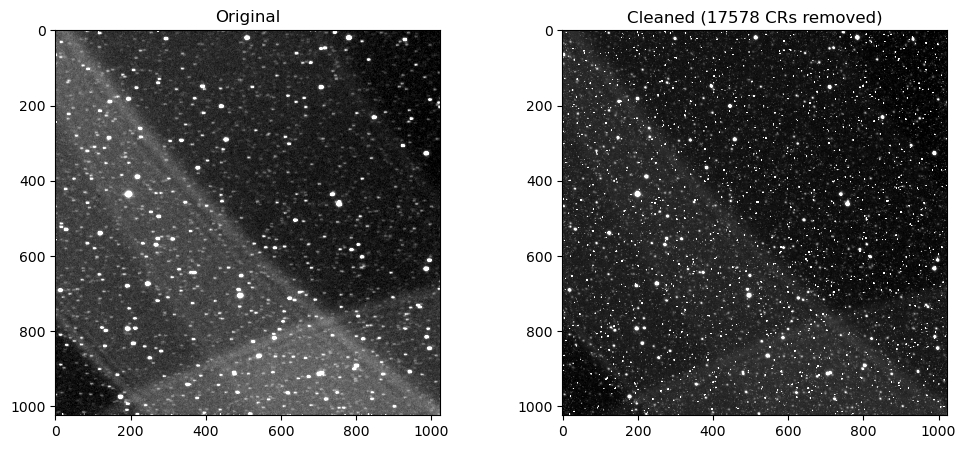

In [31]:
%matplotlib inline
from astropy.io import fits
fpath ="/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/testnight/FBOGLE-2024-BLG-0034v0029_crclean.fits"
# Verificar que se escribieron los keywords
hdr = fits.getheader(fpath)
print(hdr)
print(f"CRCLEAN  = {hdr.get('CRCLEAN')}")   # True
print(f"NCOSMIC  = {hdr.get('NCOSMIC')}")   # 127
print(f"CRSIGCLP = {hdr.get('CRSIGCLP')}")  # 4.5
print(f"CRNITER  = {hdr.get('CRNITER')}")   # 4
print(f"ATROMET  = {hdr.get('ASTROMET')}")
import matplotlib.pyplot as plt
from astropy.io import fits

# Comparar antes/después (si guardaste backup)
# O usar una imagen de test

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original (si existe backup)
data_orig = fits.getdata(fpath)
axes[0].imshow(data_orig, vmin=np.percentile(data_orig, 5), 
               vmax=np.percentile(data_orig, 99), cmap='gray')
axes[0].set_title("Original")
fpath ="/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/testnight/BOGLE-2024-BLG-0034v0021.fit"
# Cleaned
data_clean = fits.getdata(fpath)
axes[1].imshow(data_clean, vmin=np.percentile(data_clean, 5),
               vmax=np.percentile(data_clean, 99), cmap='gray')
axes[1].set_title(f"Cleaned ({hdr['NCOSMIC']} CRs removed)")

plt.show()

In [2]:
img_files

['/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/testnight/FBOGLE-2024-BLG-0034i0003_wcs.fits',
 '/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/testnight/FBOGLE-2024-BLG-0034i0003_wcs_trans.fits',
 '/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/testnight/FBOGLE-2024-BLG-0034i0003_wcs_trans_scaled.fits',
 '/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/testnight/FBOGLE-2024-BLG-0034i0004_wcs.fits',
 '/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/testnight/FBOGLE-2024-BLG-0034i0004_wcs_trans.fits',
 '/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/testnight/FBOGLE-2024-BLG-0034i0004_wcs_trans_scaled.fits',
 '/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/testnight/FBOGLE-2024-BLG-0034i0005_wcs.fits',
 '/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/testnight/FBOGLE-2024-BLG-0034i0005_wcs_trans.fit

In [9]:
#images = image_collection(night_dir, meta_csv)
df = images.summary.to_pandas()
df[~df["file"].str.contains("trans")]


,file,simple,bitpix,naxis,naxis1,naxis2,extend,ccdsize,ccdsum,pixsize1,...,bkg_mean,scl_mean,scl_std,aligned,scaled,bkg_sub,bkg_add,history,bscale,bzero
0,BOGLE-2024-BLG-0034i0003.fit,True,-64,2,1024,1024,True,"[1:1024,1:1024]",1 1,24.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BOGLE-2024-BLG-0034i0004.fit,True,-64,2,1024,1024,True,"[1:1024,1:1024]",1 1,24.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BOGLE-2024-BLG-0034i0005.fit,True,-64,2,1024,1024,True,"[1:1024,1:1024]",1 1,24.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BOGLE-2024-BLG-0034i0006.fit,True,-64,2,1024,1024,True,"[1:1024,1:1024]",1 1,24.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BOGLE-2024-BLG-0034i0007.fit,True,-64,2,1024,1024,True,"[1:1024,1:1024]",1 1,24.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,flatv0024.fit,True,16,2,1024,1024,NaN,"[1:1024,1:1024]",1 1,24.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,32768.0
499,flatv0025.fit,True,16,2,1024,1024,NaN,"[1:1024,1:1024]",1 1,24.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,32768.0
500,flatv0026.fit,True,16,2,1024,1024,NaN,"[1:1024,1:1024]",1 1,24.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,32768.0
501,skyflatI.fits,True,-64,2,1024,1024,True,"[1:1024,1:1024]",1 1,24.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
images = image_collection(night_dir, meta_csv)
df = images.summary.to_pandas()
myimages = df[(df["imagetyp"]=="object") & (df["calibz"]=="subtracted bias") & (df["calibf"]=="no")].file
myflats =  df[(df["imagetyp"]=="flat") & (df["calibz"]=="subtracted bias") & (df["calibf"]=="no")].file
myimages, myflats
df["astromet"].value_counts()
df[~df["filename"].str.contains("comb") & (df["object"]==objname)
   & (df["astromet"]=="yes")]["file"].values



array(['FBOGLE-2024-BLG-0034i0003_wcs.fits',
       'FBOGLE-2024-BLG-0034i0004_wcs.fits',
       'FBOGLE-2024-BLG-0034i0005_wcs.fits',
       'FBOGLE-2024-BLG-0034i0006_wcs.fits',
       'FBOGLE-2024-BLG-0034i0007_wcs.fits',
       'FBOGLE-2024-BLG-0034i0008_wcs.fits',
       'FBOGLE-2024-BLG-0034i0009_wcs.fits',
       'FBOGLE-2024-BLG-0034i0010_wcs.fits',
       'FBOGLE-2024-BLG-0034i0011_wcs.fits',
       'FBOGLE-2024-BLG-0034i0012_wcs.fits',
       'FBOGLE-2024-BLG-0034i0013_wcs.fits',
       'FBOGLE-2024-BLG-0034i0014_wcs.fits',
       'FBOGLE-2024-BLG-0034i0015_wcs.fits',
       'FBOGLE-2024-BLG-0034i0016_wcs.fits',
       'FBOGLE-2024-BLG-0034i0017_wcs.fits',
       'FBOGLE-2024-BLG-0034i0018_wcs.fits',
       'FBOGLE-2024-BLG-0034i0019_wcs.fits',
       'FBOGLE-2024-BLG-0034i0020_wcs.fits',
       'FBOGLE-2024-BLG-0034i0021_wcs.fits',
       'FBOGLE-2024-BLG-0034i0022_wcs.fits',
       'FBOGLE-2024-BLG-0034i0023_wcs.fits',
       'FBOGLE-2024-BLG-0034i0024_wcs.fits',
       'FB

/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250614/FBOGLE-2024-BLG-0034i0004_wcs.fits

===== HEADER INFO =====
EXPTIME: 300.0
GAIN: 2.2
RDNOISE: 15
FILTER: I
SATURATE: None

===== IMAGE STATS =====
Min: 4230.59
Max: 68024.77
Mean: 4681.51
Median: 4675.08
Std: 121.52

===== SATURATION CHECK =====
Saturation level assumed: 65000
Saturated pixels: 11
Fraction saturated: 0.0000


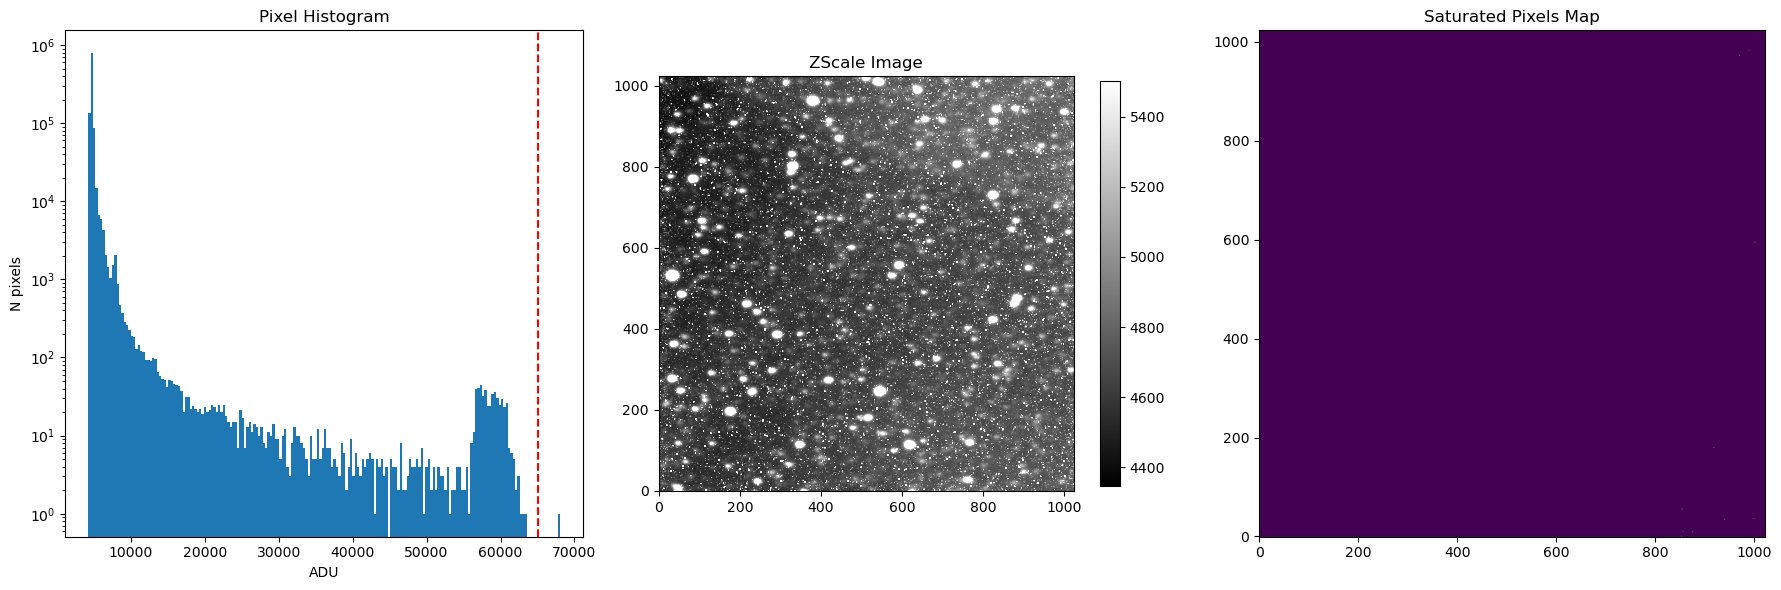


WCS OK


<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject



===== SOURCES DETECTED =====
Number of sources: 146
 id     xcentroid      ...        flux                 mag         
--- ------------------ ... ------------------ ---------------------
  1 234.38476422583076 ...  2.263698296629517   -0.8870463601330869
  2  387.3468341170549 ...  2.674604648569128   -1.0681489877303076
  3 1.0588363217001902 ... 1.6889261898414756   -0.5690266756667262
  4  44.38536471102103 ...  4.163824216238934   -1.5487309666442315
  5  705.1600211158266 ... 1.9994892378145106   -0.7522976772499326
  6 240.66130935340004 ... 4.1033332719413815   -1.5328419792849108
  7  757.8875136473566 ...  5.146070433238037   -1.7786893150420622
  8  888.6252254409886 ... 1.0168185779403076 -0.018108681156514293
  9 170.54690506922816 ...  1.901604354186567   -0.6978004078607775
 10  888.0507362425985 ... 1.5116707893315564   -0.4486430527410257


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.visualization import ZScaleInterval
from astropy.wcs import WCS
from pathlib import Path

# === PATH A LA IMAGEN PROBLEMÁTICA ===
fits_path = Path('/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250614/FBOGLE-2024-BLG-0034i0004_wcs.fits')

def check_saturation(fits_path):
    # === CARGAR IMAGEN ===
    with fits.open(fits_path) as hdul:
        data = hdul[0].data.astype(float)
        header = hdul[0].header

    print("\n===== HEADER INFO =====")
    print("EXPTIME:", header.get("EXPTIME"))
    print("GAIN:", header.get("GAIN"))
    print("RDNOISE:", header.get("RDNOISE"))
    print("FILTER:", header.get("FILTERS"))
    print("SATURATE:", header.get("SATURATE"))

    # === ESTADÍSTICAS GLOBALES ===
    mean, median, std = sigma_clipped_stats(data, sigma=3)

    print("\n===== IMAGE STATS =====")
    print(f"Min: {np.nanmin(data):.2f}")
    print(f"Max: {np.nanmax(data):.2f}")
    print(f"Mean: {mean:.2f}")
    print(f"Median: {median:.2f}")
    print(f"Std: {std:.2f}")

    # === CHEQUEO DE SATURACIÓN ===
    saturation_level = header.get("SATURATE", 65000)

    n_saturated = np.sum(data >= 0.95 * saturation_level)
    total_pixels = data.size

    print("\n===== SATURATION CHECK =====")
    print(f"Saturation level assumed: {saturation_level}")
    print(f"Saturated pixels: {n_saturated}")
    print(f"Fraction saturated: {n_saturated/total_pixels:.4f}")

    # === HISTOGRAMA, VISUALIZACIÓN ZSCALE Y MAPA DE SATURACIÓN EN UNA FIGURA ===
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Histograma
    axes[0].hist(data.flatten(), bins=200, log=True)
    axes[0].axvline(saturation_level, color='r', linestyle='--')
    axes[0].set_title("Pixel Histogram")
    axes[0].set_xlabel("ADU")
    axes[0].set_ylabel("N pixels")

    # Visualización ZScale
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(data)
    im = axes[1].imshow(data, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    axes[1].set_title("ZScale Image")
    plt.colorbar(im, ax=axes[1], shrink=0.8)

    # Mapa de Saturación
    sat_mask = data >= 0.95 * saturation_level
    axes[2].imshow(sat_mask, origin="lower")
    axes[2].set_title("Saturated Pixels Map")

    plt.tight_layout()
    plt.show()

    # === VERIFICAR WCS ===
    try:
        wcs = WCS(header)
        print("\nWCS OK")
    except Exception as e:
        print("\nWCS problem:", e)
    return data
        
for i in range(2, 9):  # Assuming there are 5 images numbered from 1 to 5
    if i == 4:
        f = f'/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250614/FBOGLE-2024-BLG-0034i000{i}_wcs.fits'
        print(f)
        data = check_saturation(Path(f)) 
        from photutils.detection import DAOStarFinder
        from astropy.stats import mad_std

        mean, median, std = sigma_clipped_stats(data, sigma=3)
        data_sub = data - median

        data_clean = np.nan_to_num(data_sub)

        bkg_sigma = mad_std(data_clean)

        daofind = DAOStarFinder(
            fwhm=7,
            threshold=5 * bkg_sigma
        )

        sources = daofind(data_clean)

        print("\n===== SOURCES DETECTED =====")
        print(f"Number of sources: {len(sources) if sources is not None else 0}")

        if sources is not None:
            print(sources[:10])


[]
Error processing star at index 0: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 2: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 3: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 4: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 5: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 7: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 8: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 9: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 10: zero-size array to reduction operation fmax which has no identity
[]
Error processing star at index 11: zero-size array to reduction opera

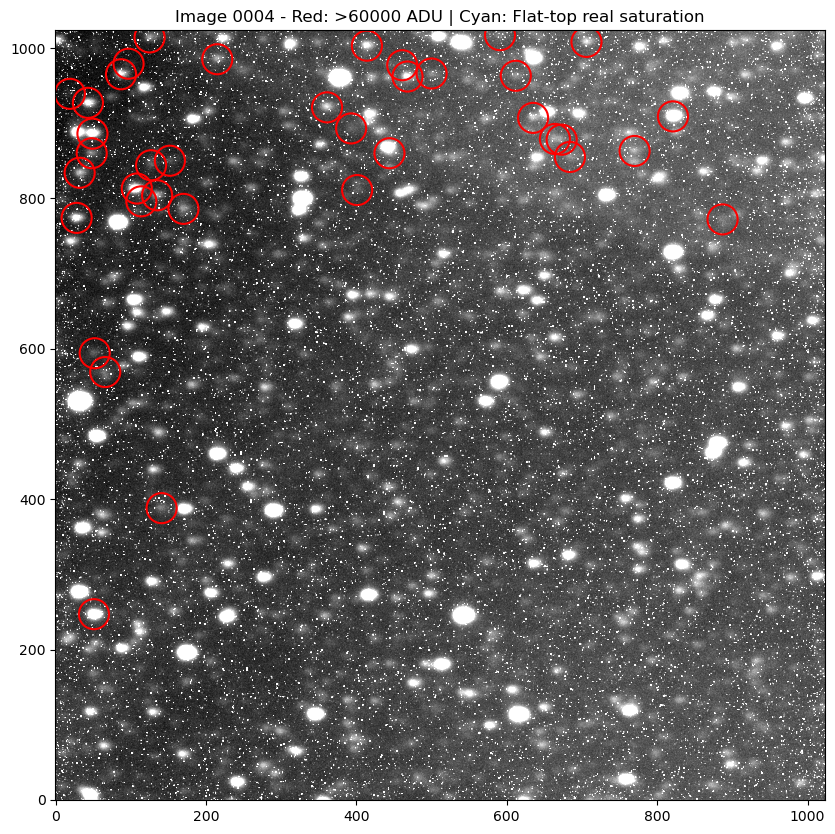

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval
from astropy.wcs import WCS
from photutils.aperture import CircularAperture
import pandas as pd
from pathlib import Path

# === CONFIG ===
fits_path = Path('/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250614/FBOGLE-2024-BLG-0034i0004_wcs.fits')
catalog_path = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/objetos/OGLE-2024-BLG-0034/OGLE-2024-BLG-0034_phot_cat.csv"

sat_threshold = 60000
stamp_size = 15

# === LOAD IMAGE + WCS ===
with fits.open(fits_path) as hdul:
    data = hdul[0].data.astype(float)
    header = hdul[0].header

wcs = WCS(header)

# === LOAD CATALOG ===
catalog = pd.read_csv(catalog_path)

# Convert RA/DEC to pixel coordinates
x_pix, y_pix = wcs.all_world2pix(catalog['RA'].values,
                                 catalog['DEC'].values, 0)

catalog['x'] = x_pix
catalog['y'] = y_pix

# Keep only stars inside image
mask_in = (
    (catalog['x'] > stamp_size) &
    (catalog['x'] < data.shape[1] - stamp_size) &
    (catalog['y'] > stamp_size) &
    (catalog['y'] < data.shape[0] - stamp_size)
)

#catalog = catalog[mask_in]

suspected_sat = []
real_sat = []

# === Saturation diagnostic ===
for i, row in catalog.iterrows():
    try:
        x = int(row['x'])
        y = int(row['y'])

        stamp = data[x-stamp_size:x+stamp_size,y-stamp_size:y+stamp_size]
              #      x-stamp_size:x+stamp_size]

        peak = np.nanmax(stamp)

        if peak > sat_threshold:
            suspected_sat.append((x, y))

            # check flat-top
            n_max = np.sum(stamp == peak)
            if n_max > 3:
                real_sat.append((x, y))
    except Exception as e:
        print(stamp)
        print(f"Error processing star at index {i}: {e}")

print("Stars with peak >60000 ADU:", len(suspected_sat))
print("Stars with real flat-top saturation:", len(real_sat))

# === PLOT ===
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(data)

plt.figure(figsize=(10,10))
plt.imshow(data, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)

if suspected_sat:
    ap1 = CircularAperture(suspected_sat, r=20)
    ap1.plot(color='red', lw=1.5)

if real_sat:
    ap2 = CircularAperture(real_sat, r=20)
    ap2.plot(color='cyan', lw=2)

plt.title("Image 0004 - Red: >60000 ADU | Cyan: Flat-top real saturation")
plt.show()

In [ ]:
# Debug: imprimir info crítica antes de la fotometría
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
i = fits_dir+"/OGLE-2024-BLG-0034_v_comb.fits"
print("\n=== DEBUG: Pre-aperture photometry ===")
print("Current file being processed:", i)  # 'i' es el path de la imagen en el loop

try:
    with fits.open(i) as hdul:
        hdr = hdul[0].header
        data = hdul[0].data
        print("Image shape (data array):", data.shape if data is not None else "No data")
        print("Data type:", data.dtype if data is not None else "None")
        print("Min / Max / Mean pixel value:", 
              np.min(data), np.max(data), np.mean(data) if data is not None else "N/A")
        
        wcs_obj = WCS(hdr)
        print("WCS object valid?", wcs_obj.pixel_n_dim == 2)
        print("WCS:", wcs_obj)
        
        # Posiciones del target (AutoPhOT las usa de aquí o del input)
        print("Target RA/DEC from autophot_input:", 
              autophot_input.get('target_ra'), autophot_input.get('target_dec'))
        print("From header (if present):")
        print("  OBJ_RA / OBJ_DEC:", hdr.get('OBJ_RA'), hdr.get('OBJ_DEC'))
        print("  RA2000 / DEC2000:", hdr.get('RA2000'), hdr.get('DEC2000'))
        print("  CRVAL1 / CRVAL2 (reference pixel):", hdr.get('CRVAL1'), hdr.get('CRVAL2'))
        
        # Chequeo si el target cae dentro de la imagen
        if 'target_ra' in autophot_input and 'target_dec' in autophot_input:
            try:
                pix_x, pix_y = wcs_obj.all_world2pix(
                    autophot_input['target_ra']*15, autophot_input['target_dec'], 0
                )
                print(f"Target pixel position (x,y): {pix_x:.2f}, {pix_y:.2f}")
                if 0 <= pix_x < data.shape[1] and 0 <= pix_y < data.shape[0]:
                    print("→ Target está DENTRO del FOV")
                    print("Valor en el pixel del target:", data[int(pix_y), int(pix_x)])
                else:
                    print("→ Target FUERA del FOV o en borde → posible causa del fallo")
            except Exception as e:
                print("Error proyectando target con WCS:", str(e))
except Exception as e:
    print("Error cargando header/imagen para debug:", str(e))

print("=====================================\n")


=== DEBUG: Pre-aperture photometry ===
Current file being processed: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20240314/OGLE-2024-BLG-0034/phot/OGLE-2024-BLG-0034_v_comb.fits
Image shape (data array): (1024, 1024)
Data type: >f8
Min / Max / Mean pixel value: 476.8575174607387 12366.061400658551 589.217485859812
WCS object valid? True
WCS: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 266.042423556  -39.1475733313  
CRPIX : 401.39899826  763.355239868  
CD1_1 CD1_2  : -0.000155236437064  -7.4666251735899e-07  
CD2_1 CD2_2  : 7.6163446755e-07  -0.000155441121549  
NAXIS : 1024  1024
Target RA/DEC from autophot_input: 17.736222 -39.11322
From header (if present):
  OBJ_RA / OBJ_DEC: 266.04333 -39.11322
  RA2000 / DEC2000: 17:44:10.5 -39:06:52.2
  CRVAL1 / CRVAL2 (reference pixel): 266.042423556 -39.1475733313
Target pixel position (x,y): 396.93, 541.33
→ Target está DENTRO del FOV
Valor en el pixel del target: 613.772931


→ Test test_1: {'DETECT_THRESH': 1.2, 'ANALYSIS_THRESH': 1.2, 'DETECT_MINAREA': 4, 'SEEING_FWHM': 1.8, 'BACK_SIZE': 48}
Configuración customizada aplicada a default.sex
      ✓ Catálogo generado: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/FBOGLE-2025-BLG-0451v0003_wcs_cat_test_1.txt
   Detectadas: 786
   Matched < 1.0 arcsec: 259 (33.0%)
   RMS ΔRA/ΔDEC: 0.337/0.348 arcsec
   Bias median ΔRA/ΔDEC: -0.579/-0.461 arcsec
   Plot guardado: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/FBOGLE-2025-BLG-0451v0003_wcs_test_test_1.png

→ Test test_2: {'DETECT_THRESH': 1.5, 'ANALYSIS_THRESH': 1.5, 'DETECT_MINAREA': 6, 'SEEING_FWHM': 2.5, 'BACK_SIZE': 64}
Configuración customizada aplicada a default.sex
      ✓ Catálogo generado: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/FBOGLE-2025-BLG-0451v0003_wcs_cat_test_2.txt
   Detectadas: 505
   Matched < 

In [ ]:
import re

qc_dir = night_dir / "qc_outputs"
sex_cat = sorted([qc_dir / f for f in os.listdir(qc_dir) if f.endswith("_cat.txt")])

for i in range(len(sex_cat)):
    path = sex_cat[i]
    # try to extract column names from the comment header (if present)
    with open(path, "r") as fh:
        header_text = "".join([ln for ln in fh if ln.startswith("#")])
    col_names = re.findall(r"\d+\s+([A-Z0-9_]+)", header_text)

    # read whitespace-separated SExtractor catalog; ignore comment lines
    df_sex = pd.read_csv(path, delim_whitespace=True, comment="#", header=None,
                        names=col_names if col_names else None)

    # example: get 4th row values (same as .iloc[3].values)
    df_sex

    %matplotlib inline
    # buscar imagen correspondiente al catálogo (el nombre quitando "_cat.txt")
    from astropy.io import fits
    from astropy.visualization import ZScaleInterval, ImageNormalize
    import matplotlib.pyplot as plt

    image_base = path.name.replace("_cat.txt", ".fits")  # ej. 'FBOGLE-..._wcs'


    im_path = night_dir/image_base
    with fits.open(im_path) as hdul:
        data = hdul[0].data
    if data is None:
        print(f"No hay datos en {im_path}")
    else:
        data = data.squeeze()
        if data.ndim > 2:
            data = data[0]
        norm = ImageNormalize(data, interval=ZScaleInterval())
        plt.figure(figsize=(8, 8))
        plt.imshow(data, origin='lower', cmap='gray', norm=norm)
        # si hay columnas X_IMAGE/Y_IMAGE, dibujar fuentes
        if {'X_IMAGE', 'Y_IMAGE'}.issubset(df_sex.columns):
            plt.scatter(df_sex['X_IMAGE'], df_sex['Y_IMAGE'],
                        s=15, edgecolor='red', facecolor='none', linewidth=0.7)
        plt.title(f"Image: {im_path.name}")
        plt.colorbar(label='counts')
        plt.show()
        df_sex["ELLIPTICITY"].hist()
        med=df_sex["ELLIPTICITY"].median()
        mea = df_sex["ELLIPTICITY"].mean()
        plt.axvline(df_sex["ELLIPTICITY"].median(), color="r", label = f"median {med}")
        plt.axvline(df_sex["ELLIPTICITY"].mean(),color="k", label = f"mean {mea}")
        st = df_sex["ELLIPTICITY"].std()
        plt.title(f"ellipticity, std={st}")
        plt.legend()
        plt.show()
        df_sex[df_sex["FWHM_IMAGE"]>0]["FWHM_IMAGE"].hist()
        plt.title("fwhm")
        plt.show()

In [ ]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize

# Suponiendo que night_dir ya está definido
qc_dir = night_dir / "qc_outputs"
sex_cat = sorted([qc_dir / f for f in os.listdir(qc_dir) if f.endswith("_cat.txt")])

for path in sex_cat:
    # ── Leer encabezado para nombres de columnas ─────────────────────────
    with open(path, "r") as fh:
        header_text = "".join(ln for ln in fh if ln.startswith("#"))
    col_names = re.findall(r"\d+\s+([A-Z0-9_]+)", header_text)

    # Leer catálogo SExtractor
    df_sex = pd.read_csv(path, delim_whitespace=True, comment="#", header=None,
                         names=col_names if col_names else None)

    if df_sex.empty:
        print(f"Catálogo vacío: {path.name}")
        continue

    # ── Buscar imagen correspondiente ─────────────────────────────────────
    image_base = path.name.replace("_cat.txt", ".fits")
    im_path = night_dir / image_base

    if not im_path.exists():
        print(f"No se encontró imagen: {im_path}")
        continue

    with fits.open(im_path) as hdul:
        data = hdul[0].data
        if data is None:
            print(f"No hay datos en {im_path}")
            continue
        data = data.squeeze()
        if data.ndim > 2:
            data = data[0]

    # Normalización
    norm = ImageNormalize(data, interval=ZScaleInterval())

    # ── Figura ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 9))

    ax.imshow(data, origin='lower', cmap='gray_r', norm=norm)
    ax.set_title(f"{im_path.name}", fontsize=13)
    ax.axis('off')

    # ── Dibujar fuentes con colores según FWHM ────────────────────────────
    if {'X_IMAGE', 'Y_IMAGE', 'FWHM_IMAGE'}.issubset(df_sex.columns):
        # Fuentes válidas (FWHM > 0) → blanco
        valid = df_sex[df_sex["FWHM_IMAGE"] > 0]
        ax.scatter(valid['X_IMAGE'], valid['Y_IMAGE'],
                   s=18, edgecolor='white', facecolor='none',
                   linewidth=1.1, label=f'Valid FWHM > 0 ({len(valid)})')

        # Fuentes problemáticas (FWHM ≤ 0) → rojo
        invalid = df_sex[df_sex["FWHM_IMAGE"] <= 0]
        if not invalid.empty:
            ax.scatter(invalid['X_IMAGE'], invalid['Y_IMAGE'],
                       s=22, edgecolor='red', facecolor='none',
                       linewidth=1.4, alpha=0.9,
                       label=f'Bad FWHM ≤ 0 ({len(invalid)})')

        ax.legend(loc='upper right', fontsize=9, framealpha=0.85)

    # Colorbar
    plt.colorbar(ax.imshow(data, origin='lower', cmap='gray_r', norm=norm),
                 ax=ax, fraction=0.046, pad=0.04, label='counts')

    plt.tight_layout()
    plt.show()
    break

In [ ]:
%matplotlib inline
srcs = df_sex[df_sex["FWHM_IMAGE"]>0]
plt.plot(srcs["THETA_IMAGE"].values, srcs["ELLIPTICITY"].values, ".")
plt.show()

In [ ]:
source = df_sex[df_sex['NUMBER'] == 103]
if source.empty:
    print("No se encontró la fuente")
else:
    x = source['X_IMAGE'].iloc[0]
    y = source['Y_IMAGE'].iloc[0]
    print(f"Fuente encontrada → X={x:.1f}, Y={y:.1f}, FWHM={source['FWHM_IMAGE'].iloc[0]:.2f}")

    # ── Parámetros del zoom ──────────────────────────────────────────
    zoom_size = 60          # radio en píxeles (tamaño total = 2*zoom_size)
    cutout_half = zoom_size // 2

    # Leer la imagen
    with fits.open(im_path) as hdul:
        data = hdul[0].data.astype(float).squeeze()

    # Recortar (con protección por bordes)
    x_int, y_int = int(x), int(y)
    x_min = max(0, x_int - cutout_half)
    x_max = min(data.shape[1], x_int + cutout_half + 1)
    y_min = max(0, y_int - cutout_half)
    y_max = min(data.shape[0], y_int + cutout_half + 1)

    cutout = data[y_min:y_max, x_min:x_max]

    # ── Graficar el zoom ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 7))

    norm = ImageNormalize(data, interval=ZScaleInterval())
    ax.imshow(cutout, origin='lower', cmap='gray', norm=norm)

    # Marcar el centro exacto (la posición real de la fuente)
    center_x = x - x_min
    center_y = y - y_min
    ax.scatter(center_x, center_y, s=200, marker='+', color='lime', linewidth=2.5,
               label=f"Centro fuente (X={x:.1f}, Y={y:.1f})")

    ax.set_title(f"Zoom fuente (size ≈ {zoom_size*2}px) | FWHM {source['FWHM_IMAGE'].iloc[0]:.2f}")
    ax.legend(loc='upper right', fontsize=10)
    ax.set_xlabel("píxeles relativos")
    ax.set_ylabel("píxeles relativos")

    # Opcional: agregar círculo con tamaño FWHM aproximado
    from matplotlib.patches import Circle
    fwhm = source['FWHM_IMAGE'].iloc[0]
    if fwhm > 0:
        circle = Circle((center_x, center_y), radius=fwhm/2, color='cyan', 
                        fill=False,
                        linewidth=1.8, linestyle='--', alpha=0.8,
                        label=f"FWHM/2 ≈ {fwhm/2:.1f} px")
        ax.add_patch(circle)
        ax.legend()

    plt.tight_layout()
    plt.show()

### SEXtractor settings testing

In [ ]:
# ==================== CELDA 1: Imports y setup ====================
import subprocess
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import itertools
import warnings
warnings.filterwarnings("ignore")

test_images = list(Path(night_dir).glob("*_wcs.fits"))  # cambialo


In [ ]:
from pathlib import Path
from shutil import copyfile
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
def ensure_sextractor_files(outdir: Path, sex_config: dict = None):
    """
    Genera archivos SExtractor usando sex_config (solo sobrescribe lo que se pasa).
    Todos los demás parámetros usan valores por defecto razonables para CASLEO.
    """
    outdir.mkdir(parents=True, exist_ok=True)

    # Valores por defecto (ajustados a tu instrumento ~0.53"/pix, gain ~2)
    defaults = {
        "DETECT_MINAREA": 5,
        "DETECT_THRESH": 1.8,
        "ANALYSIS_THRESH": 1.5,
        "DEBLEND_NTHRESH": 32,
        "DEBLEND_MINCONT": 0.005,
        "PHOT_APERTURES": "3,5,8",
        "PHOT_AUTOPARAMS": "2.5,3.5",
        "SATUR_LEVEL": 60000,
        "GAIN": 2.0,
        "PIXEL_SCALE": 0.53,
        "SEEING_FWHM": 3.5,          # valor inicial razonable (ajustar después)
        "BACK_SIZE": 64,
        "BACK_FILTERSIZE": 3,
        "VERBOSE_TYPE": "QUIET"
    }

    # Combinar: lo que venga en sex_config sobreescribe defaults
    if sex_config is None:
        config = defaults.copy()
    else:
        config = defaults.copy()
        config.update(sex_config)   # ← clave: solo actualiza las que existen

    # ---------------- default.param (fijo para QC) ----------------
    (outdir / "default.param").write_text(
        "NUMBER\nX_IMAGE\nY_IMAGE\nFLUX_AUTO\nFLUXERR_AUTO\nMAG_AUTO\nMAGERR_AUTO\n"
        "FWHM_IMAGE\nELLIPTICITY\nTHETA_IMAGE\nFLAGS\nSNR_WIN\n"
        "FLUX_APER(1)\nFLUXERR_APER(1)\n"
    )

    # ---------------- default.conv (fijo) ----------------
    conv_file = outdir / "default.conv"
    official = Path("/home/knowogrodski/miniconda3/envs/hsh_images/share/sextractor/default.conv")
    if official.exists():
        copyfile(official, conv_file)
    else:
        conv_file.write_text("""CONV NORM
3 3
1 2 1
2 4 2
1 2 1
""")

    # ---------------- default.sex (con valores combinados) ----------------
    sex_text = f"""CATALOG_TYPE       ASCII_HEAD
DETECT_TYPE        CCD
DETECT_MINAREA     {config["DETECT_MINAREA"]}
DETECT_THRESH      {config["DETECT_THRESH"]}
ANALYSIS_THRESH    {config["ANALYSIS_THRESH"]}
DEBLEND_NTHRESH    {config["DEBLEND_NTHRESH"]}
DEBLEND_MINCONT    {config["DEBLEND_MINCONT"]}
CLEAN              Y
CLEAN_PARAM        1.0
PHOT_APERTURES     {config["PHOT_APERTURES"]}
PHOT_AUTOPARAMS    {config["PHOT_AUTOPARAMS"]}
PHOT_FLUXFRAC      0.5
SATUR_LEVEL        {config["SATUR_LEVEL"]}
MAG_ZEROPOINT      25.0
GAIN               {config["GAIN"]}
PIXEL_SCALE        {config["PIXEL_SCALE"]}
SEEING_FWHM        {config["SEEING_FWHM"]}
BACK_SIZE          {config["BACK_SIZE"]}
BACK_FILTERSIZE    {config["BACK_FILTERSIZE"]}
CHECKIMAGE_TYPE    NONE
MEMORY_OBJSTACK    3000
MEMORY_PIXSTACK    300000
MEMORY_BUFSIZE     1024
VERBOSE_TYPE       {config["VERBOSE_TYPE"]}
"""
    (outdir / "default.sex").write_text(sex_text.strip())

    return config

def run_sextractor(fits_path: Path, outdir: Path, sex_config: dict = None) -> Path:
    """Ejecuta SExtractor con la config que quieras."""
    sex_config = ensure_sextractor_files(outdir, sex_config)
    sex_file = outdir / "default.sex"
    param_file = outdir / "default.param"
    conv_file = outdir / "default.conv"
    cat_path = outdir / f"{fits_path.stem}_cat.txt"

    cmd = [
        "sex", str(fits_path),
        "-c", str(sex_file),
        "-CATALOG_NAME", str(cat_path),
        "-PARAMETERS_NAME", str(param_file),
        "-FILTER", "Y",
        "-FILTER_NAME", str(conv_file),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("SExtractor falló. STDOUT/STDERR:")
        print(result.stdout, result.stderr)
        raise RuntimeError("SExtractor failed")
    return cat_path
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval, ImageNormalize, AsinhStretch
from astropy.io import fits
import pandas as pd
from pathlib import Path

def plot_detections_overlay(
    fits_path: Path,
    cat_path: Path,
    output_dir: Path,
    snr_min: float = 5.0,
    flags_highlight: bool = True,
    zoom_size: int = 100,           # pixeles de zoom alrededor de saturados
    figsize: tuple = (12, 10)
):
    """
    Plotea imagen FITS + overlay de detecciones de SExtractor.
    - Verde: good sources (FLAGS=0, SNR_WIN >= snr_min)
    - Rojo: bad flags (FLAGS > 0)
    - Azul: marginales
    - Guarda full image + posibles zooms en saturación/hot pixels
    """
    output_dir.mkdir(exist_ok=True)
    base = fits_path.stem

    # Leer imagen
    with fits.open(fits_path) as hdul:
        data = hdul[0].data.astype(float)
        header = hdul[0].header

    # Normalización visual (zscale + asinh es muy bueno para astronomía)
    norm = ImageNormalize(data, interval=ZScaleInterval(), stretch=AsinhStretch(a=0.1))

    # Leer catálogo
    df = pd.read_csv(cat_path, delim_whitespace=True, comment="#", header=None,
                     names=["NUMBER", "X_IMAGE", "Y_IMAGE", "FLUX_AUTO", "FLUXERR_AUTO",
                            "MAG_AUTO", "MAGERR_AUTO", "FWHM_IMAGE", "ELLIPTICITY",
                            "THETA_IMAGE", "FLAGS", "SNR_WIN", "FLUX_APER_1", "FLUXERR_APER_1"])

    good = df[(df["FLAGS"] == 0) & (df["SNR_WIN"] >= snr_min)]
    bad = df[df["FLAGS"] > 0]
    marginal = df[(df["FLAGS"] == 0) & (df["SNR_WIN"] < snr_min)]

    print(f"  → Total detections: {len(df)} | Good (SNR>{snr_min}): {len(good)} | Bad flags: {len(bad)}")

    # Plot principal
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(data, origin='lower', norm=norm, cmap='gray_r')
    ax.set_title(f"Detections overlay - {fits_path.name}\n"
                 f"Good: {len(good)} | Bad flags: {len(bad)} | Marginal: {len(marginal)}")

    # Overlay good
    ax.scatter(good["X_IMAGE"], good["Y_IMAGE"],
               s=30, facecolor='none', edgecolor='lime', lw=1.2, label=f"Good (SNR ≥ {snr_min})")

    # Overlay bad flags (rojo)
    if flags_highlight and not bad.empty:
        ax.scatter(bad["X_IMAGE"], bad["Y_IMAGE"],
                   s=50, facecolor='none', edgecolor='red', lw=1.5, label="FLAGS > 0")

    # Overlay marginal (azul tenue)
    ax.scatter(marginal["X_IMAGE"], marginal["Y_IMAGE"],
               s=20, facecolor='none', edgecolor='cyan', alpha=0.6, label="SNR bajo")

    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlim(0, data.shape[1])
    ax.set_ylim(0, data.shape[0])
    plt.axis('off')

    full_plot = output_dir / f"{base}_detections_full.png"
    plt.savefig(full_plot, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  Guardado: {full_plot}")

    # Zoom en regiones con FLAGS > 0 o saturación (opcional pero muy útil)
    saturated = df[(df["FLAGS"] & 1) == 1]  # bit 1 = saturated
    if not saturated.empty:
        print(f"  → Detectadas {len(saturated)} fuentes saturadas → generando zooms")
        for idx, row in saturated.head(6).iterrows():  # max 6 zooms para no saturar
            x, y = int(row["X_IMAGE"]), int(row["Y_IMAGE"])
            x1, x2 = max(0, x - zoom_size//2), min(data.shape[1], x + zoom_size//2)
            y1, y2 = max(0, y - zoom_size//2), min(data.shape[0], y + zoom_size//2)

            sub = data[y1:y2, x1:x2]
            sub_norm = ImageNormalize(sub, interval=ZScaleInterval(), stretch=AsinhStretch())

            figz, axz = plt.subplots(figsize=(5,5))
            axz.imshow(sub, origin='lower', norm=sub_norm, cmap='gray_r')
            axz.scatter(row["X_IMAGE"] - x1, row["Y_IMAGE"] - y1,
                        s=100, facecolor='none', edgecolor='magenta', lw=2,
                        label=f"ID {row['NUMBER']} | FLAGS={row['FLAGS']}")
            axz.legend()
            axz.set_title(f"Zoom saturado cerca de ({x},{y})")
            axz.axis('off')

            zoom_plot = output_dir / f"{base}_zoom_sat_{idx}.png"
            plt.savefig(zoom_plot, dpi=150, bbox_inches='tight')
            plt.close(figz)
            print(f"     {zoom_plot}")

    return full_plot

def test_sextractor_configs(test_images, outdir: Path, n_configs=5):
    """
    Prueba varias configuraciones y genera los plots que pediste.
    Guarda tabla resumen para decidir los cortes de QC.
    """
    outdir.mkdir(exist_ok=True)
    configs = [
        {"DETECT_THRESH": 1.5, "SEEING_FWHM": 3.0, "GAIN": 2.0, "PIXEL_SCALE": 0.53},
        {"DETECT_THRESH": 1.8, "SEEING_FWHM": 3.5, "GAIN": 2.0, "PIXEL_SCALE": 0.53},
        {"DETECT_THRESH": 2.0, "SEEING_FWHM": 4.0, "GAIN": 2.0, "PIXEL_SCALE": 0.53},
        {"DETECT_THRESH": 2.5, "SEEING_FWHM": 3.5, "GAIN": 2.0, "PIXEL_SCALE": 0.53},
        {"DETECT_THRESH": 1.8, "SEEING_FWHM": 3.5, "BACK_SIZE": 128, "GAIN": 2.0, "PIXEL_SCALE": 0.53},
    ]

    summary = []
    for i, cfg in enumerate(configs[:n_configs]):
        print(f"Test config {i+1}: DETECT_THRESH={cfg['DETECT_THRESH']}, SEEING={cfg['SEEING_FWHM']}")
        all_cat = []
        for img in test_images:
            cat_path = run_sextractor(img, outdir / f"test_{i}", cfg)
            df = pd.read_csv(cat_path, delim_whitespace=True, comment="#", header=None,
                             names=["NUMBER","X_IMAGE","Y_IMAGE","FLUX_AUTO","FLUXERR_AUTO",
                                    "MAG_AUTO","MAGERR_AUTO","FWHM_IMAGE","ELLIPTICITY",
                                    "THETA_IMAGE","FLAGS","SNR_WIN","FLUX_APER_1","FLUXERR_APER_1"])
            good = df[(df["FLAGS"]==0) & (df["SNR_WIN"]>5)]
            all_cat.append(good)

        df_all = pd.concat(all_cat, ignore_index=True)
        
        n_good = len(df_all)
        med_fwhm = df_all["FWHM_IMAGE"].median()
        med_ellip = df_all["ELLIPTICITY"].median()

        summary.append({
            "config": i+1,
            "DETECT_THRESH": cfg["DETECT_THRESH"],
            "SEEING_FWHM": cfg["SEEING_FWHM"],
            "n_sources_good": n_good,
            "med_FWHM_pix": round(med_fwhm, 2),
            "med_seeing_arcsec": round(med_fwhm*0.53, 2),
            "med_ellip": round(med_ellip, 3),
            "%_bad_flags": round(100*(1 - n_good/len(df_all)) if len(df_all)>0 else 0, 1)
        })

        # PLOTS que pediste
        fig, axs = plt.subplots(2, 2, figsize=(12, 10))
        axs[0,0].hist(np.log10(df_all["FLUX_AUTO"]), bins=50); axs[0,0].set_title("log(FLUX_AUTO)")
        axs[0,1].hist(df_all["FWHM_IMAGE"], bins=50); axs[0,1].set_title("FWHM_IMAGE")
        axs[1,0].hist(df_all["ELLIPTICITY"], bins=50); axs[1,0].set_title("ELLIPTICITY")
        axs[1,1].hist(df_all["THETA_IMAGE"], bins=72); axs[1,1].set_title("THETA_IMAGE")
        plt.suptitle(f"Config {i+1} – n_good={n_good}")
        plt.savefig(outdir / f"hist_config_{i+1}.png", dpi=150)
        plt.close()

    pd.DataFrame(summary).to_csv(outdir / "sextractor_comparison.csv", index=False)
    print("✓ Tabla guardada: sextractor_comparison.csv")
    print("✓ Histogramas guardados. Ahora elegí la config con más fuentes buenas y FWHM estable.")

In [ ]:
test_sextractor_configs(test_images, night_dir / "sex_tuning")

Test config 1: DETECT_THRESH=1.5, SEEING=3.0
Test config 2: DETECT_THRESH=1.8, SEEING=3.5
Test config 3: DETECT_THRESH=2.0, SEEING=4.0
Test config 4: DETECT_THRESH=2.5, SEEING=3.5
Test config 5: DETECT_THRESH=1.8, SEEING=3.5
✓ Tabla guardada: sextractor_comparison.csv
✓ Histogramas guardados. Ahora elegí la config con más fuentes buenas y FWHM estable.
